# Algoritmos de Clasificación

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score

In [2]:
fresado_h1 = pd.read_csv('data/fresado_H1_norm.csv')
fresado_h2 = pd.read_csv('data/fresado_H2_norm.csv')
fresado_h3 = pd.read_csv('data/fresado_H3_norm.csv')

In [3]:
fresado = pd.concat([fresado_h1, fresado_h2, fresado_h3])

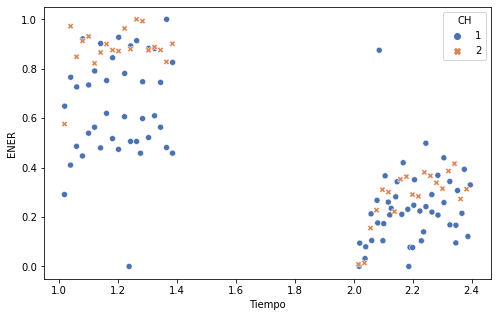

In [4]:
# Visualización de un mecanizado
plt.figure(figsize=(8,5))
var='ENER'
datos = fresado
mecanizado = 4

sns.scatterplot(data=datos[datos['Mecanizado']==mecanizado], x='Tiempo', y=var, hue='CH', palette='deep', style="CH")
plt.show()

In [5]:
ix_1 = fresado[(fresado.Tiempo < 1.4) & (fresado.ENER < 0.2) & (fresado.Mecanizado == 4)].index
ix_2 = fresado[(fresado.Tiempo > 1.8) & (fresado.ENER > 0.8) & (fresado.Mecanizado == 4)].index

fresado.drop([ ix_1[0], ix_2[0] ], axis=0, inplace=True)

In [6]:
# Pasamos la variable categórica 'Herramienta' a una variable númerica.
fresado.Herramienta.replace({'Nueva':3, 'Usada':2, 'Muy Usada':1}, inplace=True)

## Train/Test split

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit

train_test_split = StratifiedShuffleSplit(n_splits=1, test_size=.20, random_state=9)
for train_index, test_index in train_test_split.split(fresado, fresado['Herramienta']):
    X_train = fresado.iloc[train_index]
    X_test = fresado.iloc[test_index]

In [8]:
print('Datos totales:',fresado.shape[0])
print('Train:        ',X_train.shape[0])
print('Test:         ',X_test.shape[0])

Datos totales: 734
Train:         587
Test:          147


In [9]:
cols = ['RMS','AMP','ENER','P_FRQ','PCNTS','C_FRQ', 'I_FRQ','A_FRQ',
        'R_FRQ','DURATION','ASL','COUN','ABS_ENERGY', 'SIG_STRNGTH','RISE']

y_train = X_train.Herramienta
y_test = X_test.Herramienta

X_train = X_train[cols]
X_test = X_test[cols]

## Random Forest Classifier

In [10]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=1)
forest_model.fit(X_train, y_train)
prediccion = forest_model.predict(X_test)
print(accuracy_score(y_test, prediccion))

0.9387755102040817
